# Avaliação Prática 2 - CIFAR-10

In [7]:
import sys
!{sys.executable} -m pip install torch torchvision


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as T
from torchvision.datasets import CIFAR10
from torch.utils.data import ConcatDataset
from collections import Counter

SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT = "./data"
CLASS_NAMES = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]


## 1. Leitura e organização do dataset

In [9]:
raw_train = CIFAR10(root=DATA_ROOT, train=True,  download=True, transform=T.ToTensor())
raw_test  = CIFAR10(root=DATA_ROOT, train=False, download=True, transform=T.ToTensor())

img, lbl = raw_train[0]
print(f"Shape: {tuple(img.shape)} | Dtype: {img.dtype} | Range: [{img.min():.2f}, {img.max():.2f}]")
print(f"Total: {len(raw_train) + len(raw_test)} amostras | Classes: {len(CLASS_NAMES)}")


Shape: (3, 32, 32) | Dtype: torch.float32 | Range: [0.00, 1.00]
Total: 60000 amostras | Classes: 10


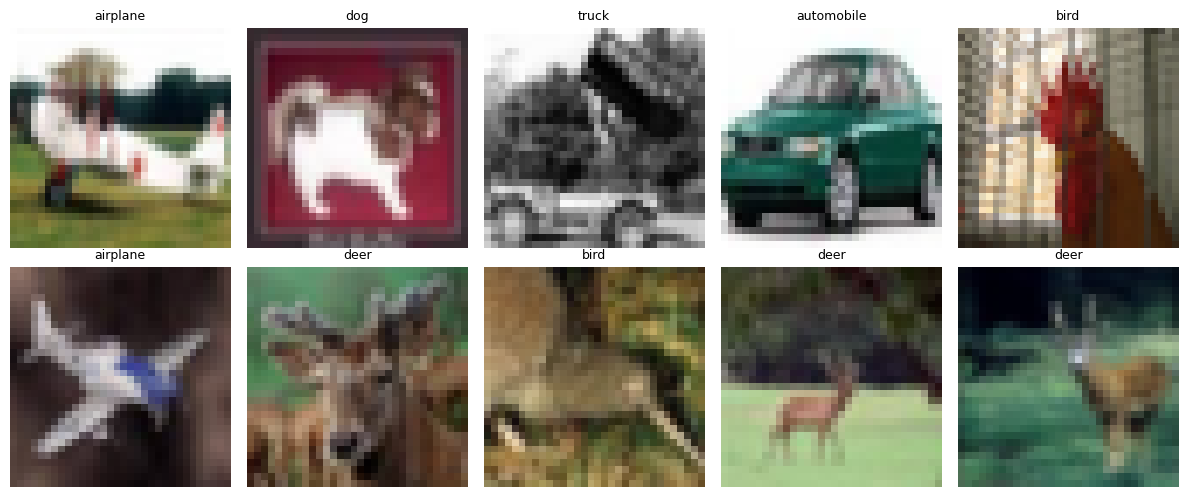

In [10]:
# 10 amostras aleatórias
rng  = np.random.default_rng(SEED)
idxs = rng.choice(len(raw_train), size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, i in zip(axes.flat, idxs):
    img, lbl = raw_train[int(i)]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(CLASS_NAMES[lbl], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [11]:
# Contagem por classe
train_counts = Counter(raw_train.targets)
test_counts  = Counter(raw_test.targets)

print(f"{'Classe':<12} {'Treino':>8}  {'Teste':>8}  {'Total':>8}")
print("-" * 42)
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<12} {train_counts[i]:>8}  {test_counts[i]:>8}  {train_counts[i]+test_counts[i]:>8}")


Classe         Treino     Teste     Total
------------------------------------------
airplane         5000      1000      6000
automobile       5000      1000      6000
bird             5000      1000      6000
cat              5000      1000      6000
deer             5000      1000      6000
dog              5000      1000      6000
frog             5000      1000      6000
horse            5000      1000      6000
ship             5000      1000      6000
truck            5000      1000      6000


In [12]:
# df_gen: dataset completo (features + labels)
combined = ConcatDataset([raw_train, raw_test])

all_images = torch.stack([combined[i][0] for i in range(len(combined))])
all_labels = torch.tensor([combined[i][1] for i in range(len(combined))])

class SimpleDataset(torch.utils.data.Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels   = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

df_gen = SimpleDataset(all_images, all_labels)
print(f"df_gen: {len(df_gen)} amostras | features: {df_gen.features.shape} | labels: {df_gen.labels.shape}")


df_gen: 60000 amostras | features: torch.Size([60000, 3, 32, 32]) | labels: torch.Size([60000])


## 2. Pré-processamento e Data Augmentation

In [13]:
# Estatísticas canônicas do CIFAR-10
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

# Treino: augmentation leve + normalização
transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

# Val/Teste: apenas normalização
transform_eval = T.Compose([
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])


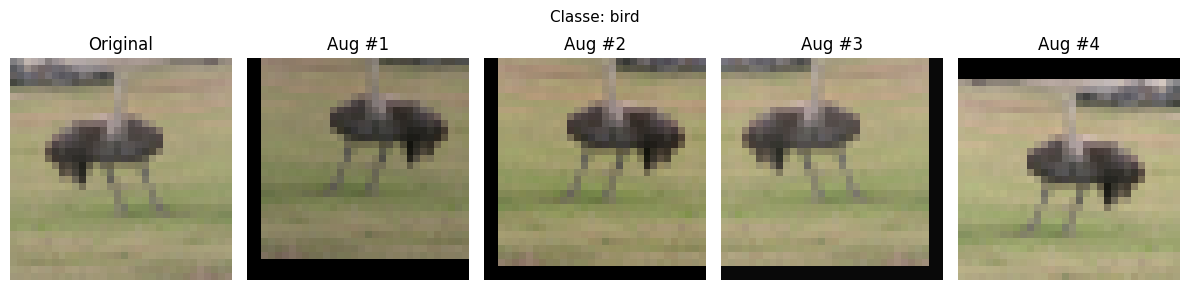

In [14]:
# Visualização: original vs augmented
raw_pil = CIFAR10(root=DATA_ROOT, train=True, download=False)
pil_img, label = raw_pil[42]

def denorm(t):
    t = t.clone()
    for c, (m, s) in enumerate(zip(MEAN, STD)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(pil_img); axes[0].set_title("Original"); axes[0].axis("off")
for i in range(1, 5):
    aug = denorm(transform_train(pil_img)).permute(1, 2, 0).numpy()
    axes[i].imshow(aug); axes[i].set_title(f"Aug #{i}"); axes[i].axis("off")
plt.suptitle(f"Classe: {CLASS_NAMES[label]}", fontsize=11)
plt.tight_layout()
plt.show()


## Etapa 3 - Divisão dos dados

In [16]:
from torch.utils.data import ConcatDataset, Subset
from sklearn.model_selection import train_test_split

# Pools com transforms distintos (mesmos 60k samples)
pool_aug = ConcatDataset([
    CIFAR10(DATA_ROOT, train=True,  download=False, transform=transform_train),
    CIFAR10(DATA_ROOT, train=False, download=False, transform=transform_train),
])
pool_eval = ConcatDataset([
    CIFAR10(DATA_ROOT, train=True,  download=False, transform=transform_eval),
    CIFAR10(DATA_ROOT, train=False, download=False, transform=transform_eval),
])

# Labels para estratificação (sem materializar tensores)
all_labels = np.array(raw_train.targets + raw_test.targets)
indices = np.arange(len(all_labels))

# 70/30 → depois 15/15 no resto
train_idx, temp_idx, y_train, y_temp = train_test_split(
    indices, all_labels, test_size=0.30, stratify=all_labels, random_state=SEED
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

train_set = Subset(pool_aug,  train_idx)
val_set   = Subset(pool_eval, val_idx)
test_set  = Subset(pool_eval, test_idx)

print(f"Treino: {len(train_set)} | Val: {len(val_set)} | Teste: {len(test_set)}")

c:\Users\enzog\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Treino: 42000 | Val: 9000 | Teste: 9000


In [17]:
def count_per_class(y):
    c = Counter(int(v) for v in y)
    return [c[i] for i in range(len(CLASS_NAMES))]

ct_train = count_per_class(y_train)
ct_val   = count_per_class(y_val)
ct_test  = count_per_class(y_test)

print(f"{'Classe':<12} {'Treino':>8} {'Val':>6} {'Teste':>6}")
print("-" * 36)
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<12} {ct_train[i]:>8} {ct_val[i]:>6} {ct_test[i]:>6}")

Classe         Treino    Val  Teste
------------------------------------
airplane         4200    900    900
automobile       4200    900    900
bird             4200    900    900
cat              4200    900    900
deer             4200    900    900
dog              4200    900    900
frog             4200    900    900
horse            4200    900    900
ship             4200    900    900
truck            4200    900    900


In [18]:
from torch.utils.data import DataLoader

BATCH_SIZE = 128

g = torch.Generator()
g.manual_seed(SEED)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, worker_init_fn=seed_worker, generator=g)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)